# MuFlex SAC Test Notebook

This copy is aligned with the current repo settings in `algo/train_sac.py`.
It loads one finished SAC run from `runs/<run_name>/`, rebuilds the MuFlex environment from that run's saved `train_config.json`, runs one deterministic evaluation episode, and plots the generated outputs.


## Step 1 - Imports and Project Setup


In [21]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from stable_baselines3 import SAC

def find_project_root(start: Path | None = None) -> Path:
    candidate = (start or Path.cwd()).resolve()
    for folder in [candidate, *candidate.parents]:
        if (folder / "algo" / "train_sac.py").exists() and (folder / "src").exists():
            return folder
    raise RuntimeError("Could not find the MuFlex project root. Open this notebook inside the repo.")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from algo.baseline import run_baseline
from algo.train_sac import IDE_RUN_DEFAULTS, configure_energyplus_runtime, resolve_fmu_path
from src.env_wrapper import MuFlex

print(f"PROJECT_ROOT = {PROJECT_ROOT}")


PROJECT_ROOT = C:\Projects\MuFlex


## Step 2 - Choose the Finished SAC Run


In [22]:
RUN_NAME = "sac_small_baseline_v2"  # change to the run folder you want to test
SAVE_RESULTS = True              # save new evaluation traces to simulation_data_<timestamp>/
PRINT_STEP_INFO = False          # set True only when you want verbose FMU step logs
GENERATE_BASELINE = True        # True: run a matched baseline in this notebook
BASELINE_OUTPUT_DIR = None       # or point to an existing baseline simulation_data_* folder
BASELINE_FMU_PATH = None         # None -> use the same FMU as the SAC run
# BASELINE_FMU_PATH = r"models\small_office\small_baseline_v1.fmu"

run_dir = PROJECT_ROOT / IDE_RUN_DEFAULTS["output_dir"] / RUN_NAME
config_path = run_dir / "train_config.json"
model_path = run_dir / "sac_muflex.zip"

settings = dict(IDE_RUN_DEFAULTS)
if config_path.exists():
    settings.update(json.loads(config_path.read_text(encoding="utf-8")))

settings["run_name"] = RUN_NAME
settings["save_env_results"] = SAVE_RESULTS
settings["print_step_info"] = PRINT_STEP_INFO

configure_energyplus_runtime(settings["energyplus_dir"])
fmu_path = resolve_fmu_path(PROJECT_ROOT, settings["fmu_path"])

print(f"run_dir = {run_dir}")
print(f"config_path = {config_path}")
print(f"model_path = {model_path}")
print(f"fmu_path = {fmu_path}")
print(f"reward_mode = {settings['reward_mode']}")
print(f"include_hour = {settings['include_hour']}")
print(f"max_total_hvac_power = {settings['max_total_hvac_power']}")

assert config_path.exists(), f"Missing {config_path}"
assert model_path.exists(), f"Missing {model_path}"
assert fmu_path.exists(), f"Missing {fmu_path}"


EnergyPlus configured for this run: C:\EnergyPlusV9.2.0\energyplus.exe
run_dir = C:\Projects\MuFlex\runs\sac_small_baseline_v2
config_path = C:\Projects\MuFlex\runs\sac_small_baseline_v2\train_config.json
model_path = C:\Projects\MuFlex\runs\sac_small_baseline_v2\sac_muflex.zip
fmu_path = C:\Projects\MuFlex\models\small_office\small_baseline_v1.fmu
reward_mode = demand_limiting_tunable
include_hour = False
max_total_hvac_power = 9000.0


## Step 3 - Rebuild the Evaluation Environment


In [23]:
fmu_configs = [{"io_type": settings["io_type"], "path": str(fmu_path)}]

env = MuFlex(
    fmu_configs=fmu_configs,
    sim_days=settings["sim_days"],
    start_date=settings["start_date"],
    step_size=settings["step_size"],
    action_type=settings["action_type"],
    max_total_hvac_power=settings["max_total_hvac_power"],
    hvac_weight=settings["hvac_weight"],
    temp_weight=settings["temp_weight"],
    max_power_weight=settings["max_power_weight"],
    reward_mode=settings["reward_mode"],
    save_results=settings["save_env_results"],
    include_hour=settings["include_hour"],
    print_step_info=settings["print_step_info"],
    print_step_interval=settings["print_step_interval"],
)

expected_steps = int(86400 * settings["sim_days"] / settings["step_size"]) + 1
print("observation_space =", env.observation_space)
print("action_space =", env.action_space)
print("expected episode steps =", expected_steps)


observation_space = Box(0.0, 1.0, (13,), float32)
action_space = Box(-1.0, 1.0, (6,), float32)
expected episode steps = 97


## Step 4 - Load the Trained SAC Model


In [24]:
model = SAC.load(model_path)
print("Model loaded:", type(model))


Model loaded: <class 'stable_baselines3.sac.sac.SAC'>


## Step 5 - Run One Deterministic Evaluation Episode


In [25]:
obs, info = env.reset(seed=settings["seed"])
terminated = False
truncated = False
steps = 0
total_reward = 0.0

while not (terminated or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += float(reward)
    steps += 1

sac_output_dir = PROJECT_ROOT / env.output_folder
env.close()

summary_df = pd.DataFrame([
    {
        "run_name": RUN_NAME,
        "steps": steps,
        "total_reward": total_reward,
        "output_dir": str(sac_output_dir),
    }
])
display(summary_df)
print(f"Saved evaluation files to: {sac_output_dir}")


 Saving results is enabled. 
 [Init] Loading FMU #1: io_type = OfficeS, path = C:\Projects\MuFlex\models\small_office\small_baseline_v1.fmu 
 [Init] Initializing FMU #1, time range = (17280000, 17366400) 
 [Reward] HVAC penalty: 0.8123770356178284 
 [Reward] Temperature penalty: 0.0 
 [Reward] Max power penalty: -0.5 
 [Reward] Total penalty: -0.5938115119934082 
 [Reward] Final Reward: 0.5938115119934082 
 [Close] Terminating all FMUs... 
 [Close] FMU #1 terminated successfully. 
 [Close] All FMUs have been processed. 
 Saved FMU #1 data to: simulation_data_20260311_162929\fmu_1_data.xlsx 
 Saved reward data to: simulation_data_20260311_162929\rewards.xlsx 


,run_name,steps,total_reward,output_dir
0,sac_small_baseline_v2,97,-26.965091,C:\Projects\MuFlex\simulation_data_20260311_16...


Saved evaluation files to: C:\Projects\MuFlex\simulation_data_20260311_162929


## Step 6 - Load the Saved Evaluation Files


In [26]:
def load_eval_outputs(output_dir):
    output_dir = Path(output_dir)
    fmu_df = pd.read_excel(output_dir / "fmu_1_data.xlsx")
    reward_df = pd.read_excel(output_dir / "rewards.xlsx")
    return fmu_df, reward_df


def latest_simulation_output(root: Path) -> Path | None:
    candidates = sorted(
        [p for p in root.glob("simulation_data_*") if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
    )
    return candidates[-1] if candidates else None


sac_fmu_df, sac_reward_df = load_eval_outputs(sac_output_dir)

baseline_fmu_df = None
baseline_reward_df = None
baseline_output_dir = Path(BASELINE_OUTPUT_DIR) if BASELINE_OUTPUT_DIR else None

if GENERATE_BASELINE:
    before = latest_simulation_output(PROJECT_ROOT)
    baseline_fmu_path = resolve_fmu_path(PROJECT_ROOT, BASELINE_FMU_PATH or settings["fmu_path"])
    run_baseline(
        fmu_configs=[{"io_type": settings["io_type"], "path": str(baseline_fmu_path)}],
        sim_days=settings["sim_days"],
        start_date=settings["start_date"],
        step_size=settings["step_size"],
        max_total_hvac_power=settings["max_total_hvac_power"],
        reward_weights=(settings["hvac_weight"], settings["temp_weight"], settings["max_power_weight"]),
        reward_mode=settings["reward_mode"],
        save_results=True,
        print_steps=False,
        action_type=settings["action_type"],
        include_hour=settings["include_hour"],
    )
    after = latest_simulation_output(PROJECT_ROOT)
    if after is None or after == before:
        raise RuntimeError("Baseline run finished, but no new simulation_data_* folder was found.")
    baseline_output_dir = after

if baseline_output_dir is not None:
    baseline_fmu_df, baseline_reward_df = load_eval_outputs(baseline_output_dir)
    print(f"Loaded baseline outputs from: {baseline_output_dir}")
else:
    print("No baseline loaded. Set BASELINE_OUTPUT_DIR or GENERATE_BASELINE=True if you want comparison plots.")

display(sac_fmu_df.head())
display(sac_reward_df.head())


 Saving results is enabled. 
 [Init] Loading FMU #1: io_type = OfficeS, path = C:\Projects\MuFlex\models\small_office\small_baseline_v1.fmu 
 [Init] Initializing FMU #1, time range = (17280000, 17366400) 
 -------------------------------------------------- 
 [Step Info] Step: 1 
   Global Action (raw input): [ 1.  1.  1.  1.  1. -1.] 
   Global Action (physical values): [[25, 25, 25, 25, 25, 10]] 
   FMU #1 raw output: [86.5      29.95      0.        0.        0.        0.       29.987658
 25.80598  26.687454 26.586292 26.63962  26.93176   0.5     ] 
   FMU #1 physical action: [25, 25, 25, 25, 25, 10] 
   Next state (normalized): [0.865      0.749375   0.         0.         0.         0.
 0.59975314 0.5161196  0.5337491  0.5317258  0.5327924  0.5386352
 0.03333334] 
   Reward: -0.0 
 -------------------------------------------------- 
 [Step Info] Step: 2 
   Global Action (raw input): [ 1.  1.  1.  1.  1. -1.] 
   Global Action (physical values): [[25, 25, 25, 25, 25, 10]] 
   FMU #1 

,Step,CoolSetP_A,CoolSetP_B,CoolSetP_C,CoolSetP_D,CoolSetP_E,ahuSAT,outRH,outTemp,outSolar,coilPower,fanPower,sysFR,sysTemp,z5Temp,z1Temp,z3Temp,z2Temp,z4Temp,outWind
0,0,24.4,24.5,23.9,24.1,24.0,12.3,84.75,30.075,0.0,0.0,0.0,0.0,30.153650,25.902156,26.808278,26.699979,26.749666,27.086171,0.25
1,1,24.5,23.6,24.1,24.7,24.2,14.4,86.50,29.950,0.0,0.0,0.0,0.0,29.987658,25.805980,26.687454,26.586291,26.639620,26.931760,0.50
2,2,24.3,23.8,24.1,24.6,23.9,14.1,88.25,29.825,0.0,0.0,0.0,0.0,29.822966,25.711393,26.574946,26.481679,26.535818,26.789378,0.75
3,3,24.1,24.0,24.1,24.5,23.9,13.7,90.00,29.700,0.0,0.0,0.0,0.0,29.659556,25.618761,26.467908,26.382901,26.436239,26.656265,1.00
4,4,24.1,24.0,24.2,24.4,24.0,13.0,90.00,29.675,0.0,0.0,0.0,0.0,29.497670,25.528356,26.364290,26.284899,26.337408,26.528323,0.75


,Step,TotalReward,HVAC_penalty,Temperature_penalty,MaxPower_penalty
0,0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0
3,3,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0


## Step 7 - Plot Helpers


In [27]:
def step_axis(df: pd.DataFrame) -> np.ndarray:
    if "Step" in df.columns:
        return df["Step"].to_numpy() + 1
    return np.arange(1, len(df) + 1)

def tick_positions(step_size: int, n_steps: int, hours: int = 4) -> list[int]:
    tick_every = max(1, int(hours * 3600 / step_size))
    ticks = list(range(1, n_steps + 1, tick_every))
    if ticks[-1] != n_steps:
        ticks.append(n_steps)
    return ticks

def office_hours_span(step_size: int) -> tuple[int, int]:
    start = int(8 * 3600 / step_size) + 1
    end = int(18 * 3600 / step_size) + 1
    return start, end

n_steps = len(sac_fmu_df)
x_ticks = tick_positions(settings["step_size"], n_steps)
office_start, office_end = office_hours_span(settings["step_size"])
zone_columns = [col for col in ["z1Temp", "z2Temp", "z3Temp", "z4Temp", "z5Temp"] if col in sac_fmu_df.columns]

print("x_ticks =", x_ticks)
print("zone_columns =", zone_columns)


x_ticks = [1, 17, 33, 49, 65, 81, 97]
zone_columns = ['z1Temp', 'z2Temp', 'z3Temp', 'z4Temp', 'z5Temp']


## Step 8 - SAC vs Baseline Summary Table


In [28]:
def occupied_mask(step_values: np.ndarray, step_size: int) -> np.ndarray:
    next_seconds = (step_values.astype(int) + 1) * int(step_size)
    hour_now = (next_seconds % 86400) // 3600
    minute_now = ((next_seconds % 3600) // 60)
    return ((hour_now > 8) | ((hour_now == 8) & (minute_now >= 15))) & ((hour_now < 18) | ((hour_now == 18) & (minute_now == 0)))


def penalty_components(
    fmu_df: pd.DataFrame,
    reward_df: pd.DataFrame,
    io_type: str,
    step_size: int,
    max_total_hvac_power: float,
    temp_low: float = 23.0,
    temp_high: float = 25.0,
):
    n = min(len(fmu_df), len(reward_df)) if len(reward_df) else len(fmu_df)
    fmu_df = fmu_df.iloc[:n].copy()
    reward_df = reward_df.iloc[:n].copy()

    if "Step" in reward_df.columns:
        step_values = reward_df["Step"].to_numpy()
    elif "Step" in fmu_df.columns:
        step_values = fmu_df["Step"].to_numpy()
    else:
        step_values = np.arange(n)

    work_mask = occupied_mask(step_values, step_size)

    if io_type == "OfficeS":
        hvac_power = fmu_df["coilPower"].to_numpy() + fmu_df["fanPower"].to_numpy()
        zone_cols = [col for col in ["z5Temp", "z1Temp", "z3Temp", "z2Temp", "z4Temp"] if col in fmu_df.columns]
    elif io_type == "OfficeM":
        hvac_power = (
            fmu_df["coilPower_bot"].to_numpy()
            + fmu_df["coilPower_mid"].to_numpy()
            + fmu_df["coilPower_top"].to_numpy()
            + fmu_df["fanPower_bot"].to_numpy()
            + fmu_df["fanPower_mid"].to_numpy()
            + fmu_df["fanPower_top"].to_numpy()
        )
        zone_cols = [col for col in ["BotMeanTemp", "MidMeanTemp", "TopMeanTemp"] if col in fmu_df.columns]
    else:
        raise ValueError(f"Unsupported io_type for notebook summary: {io_type}")

    energy_penalty = hvac_power / float(max_total_hvac_power)

    thermal_penalty = np.zeros(n, dtype=float)
    if zone_cols:
        zone_temps = fmu_df[zone_cols].to_numpy(dtype=float)
        below = np.clip(temp_low - zone_temps, 0.0, None)
        above = np.clip(zone_temps - temp_high, 0.0, None)
        deviation = below + above
        deviation = np.where(deviation > 1.0, deviation ** 2, deviation)
        thermal_penalty = deviation.sum(axis=1) * 10.0
        thermal_penalty = np.where(work_mask, thermal_penalty, 0.0)

    peak_demand_penalty = np.where(
        hvac_power > float(max_total_hvac_power),
        (2.0 * energy_penalty) ** 2,
        np.where(work_mask, -0.5, 0.0),
    )

    penalty_df = pd.DataFrame(
        {
            "Step": step_values,
            "EnergyPenalty": energy_penalty,
            "ThermalPenalty": thermal_penalty,
            "PeakDemandPenalty": peak_demand_penalty,
        }
    )

    summary = {
        "Total Reward": float(reward_df["TotalReward"].sum()) if "TotalReward" in reward_df.columns else float("nan"),
        "Thermal Penalty": float(thermal_penalty.sum()),
        "Energy Penalty": float(energy_penalty.sum()),
        "Peak Demand Penalty": float(peak_demand_penalty.sum()),
    }
    return penalty_df, summary


sac_penalty_df, sac_summary = penalty_components(
    sac_fmu_df,
    sac_reward_df,
    settings["io_type"],
    settings["step_size"],
    settings.get("max_total_hvac_power", 103_500.0),
)

comparison_rows = [{"Controller": "SAC", **sac_summary}]
baseline_penalty_df = None
if baseline_fmu_df is not None and baseline_reward_df is not None:
    baseline_penalty_df, baseline_summary = penalty_components(
        baseline_fmu_df,
        baseline_reward_df,
        settings["io_type"],
        settings["step_size"],
        settings.get("max_total_hvac_power", 103_500.0),
    )
    comparison_rows.append({"Controller": "Baseline", **baseline_summary})

comparison_df = pd.DataFrame(comparison_rows).set_index("Controller")
display(comparison_df.round(3))


,Total Reward,Thermal Penalty,Energy Penalty,Peak Demand Penalty
Controller,,,,
SAC,-26.965,1.287,35.030,4.661
Baseline,-24.199,0.372,33.708,3.654


## Step 9 - HVAC Power Plot


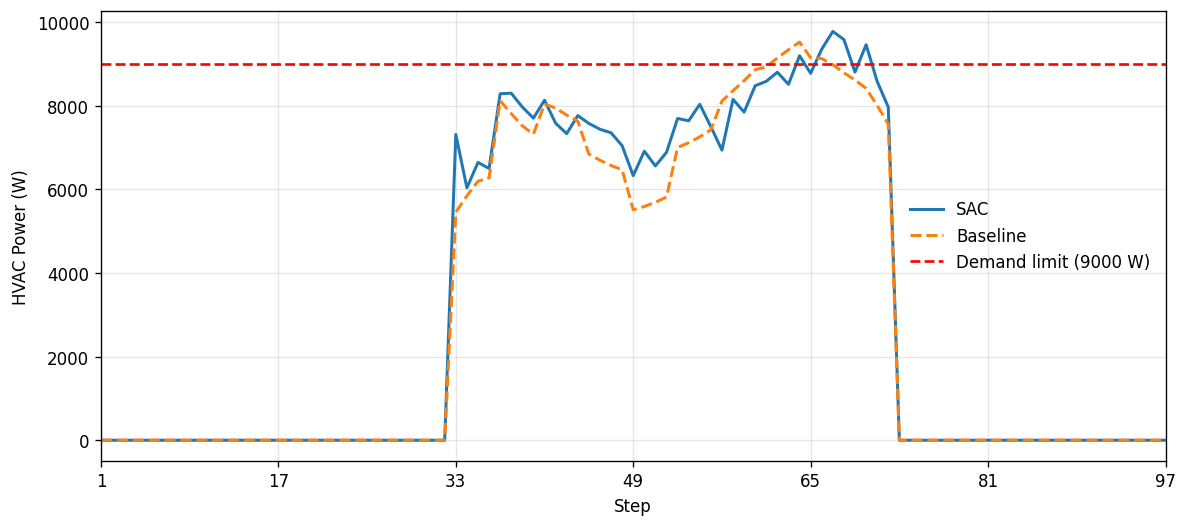

In [29]:
plt.figure(figsize=(10, 4.5), dpi=120)
hvac_sac = sac_fmu_df["coilPower"] + sac_fmu_df["fanPower"]
plt.plot(step_axis(sac_fmu_df), hvac_sac, linewidth=1.8, label="SAC")

if baseline_fmu_df is not None:
    hvac_baseline = baseline_fmu_df["coilPower"] + baseline_fmu_df["fanPower"]
    plt.plot(step_axis(baseline_fmu_df), hvac_baseline, linewidth=1.8, linestyle="--", label="Baseline")

plt.axhline(
    settings["max_total_hvac_power"],
    linestyle="--",
    linewidth=1.6,
    color="red",
    label=f"Demand limit ({settings['max_total_hvac_power']:.0f} W)",
)
plt.xlabel("Step")
plt.ylabel("HVAC Power (W)")
plt.xlim(1, n_steps)
plt.xticks(x_ticks)
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## Step 10 - Zone Temperature Plot


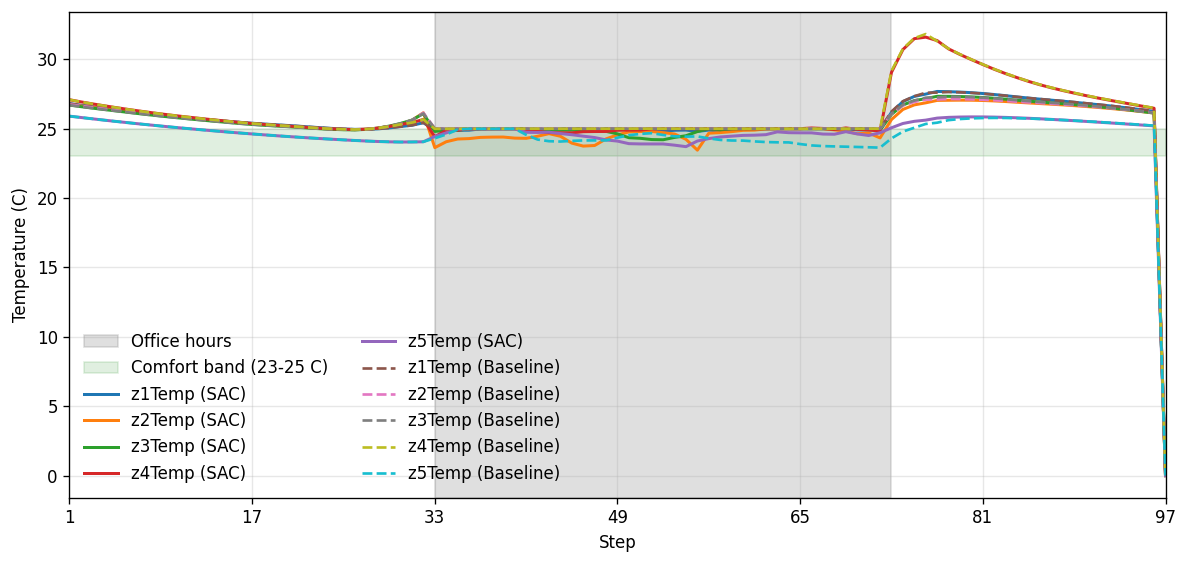

In [30]:
plt.figure(figsize=(10, 4.8), dpi=120)
plt.axvspan(office_start, office_end, color="grey", alpha=0.25, label="Office hours")
plt.axhspan(23, 25, alpha=0.12, color="green", label="Comfort band (23-25 C)")

for col in zone_columns:
    plt.plot(step_axis(sac_fmu_df), sac_fmu_df[col], linewidth=1.8, label=f"{col} (SAC)")

if baseline_fmu_df is not None:
    for col in zone_columns:
        if col in baseline_fmu_df.columns:
            plt.plot(step_axis(baseline_fmu_df), baseline_fmu_df[col], linewidth=1.6, linestyle="--", label=f"{col} (Baseline)")

plt.xlabel("Step")
plt.ylabel("Temperature (C)")
plt.xlim(1, n_steps)
plt.xticks(x_ticks)
plt.grid(True, alpha=0.3)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


## Step 11 - Reward Breakdown Plot


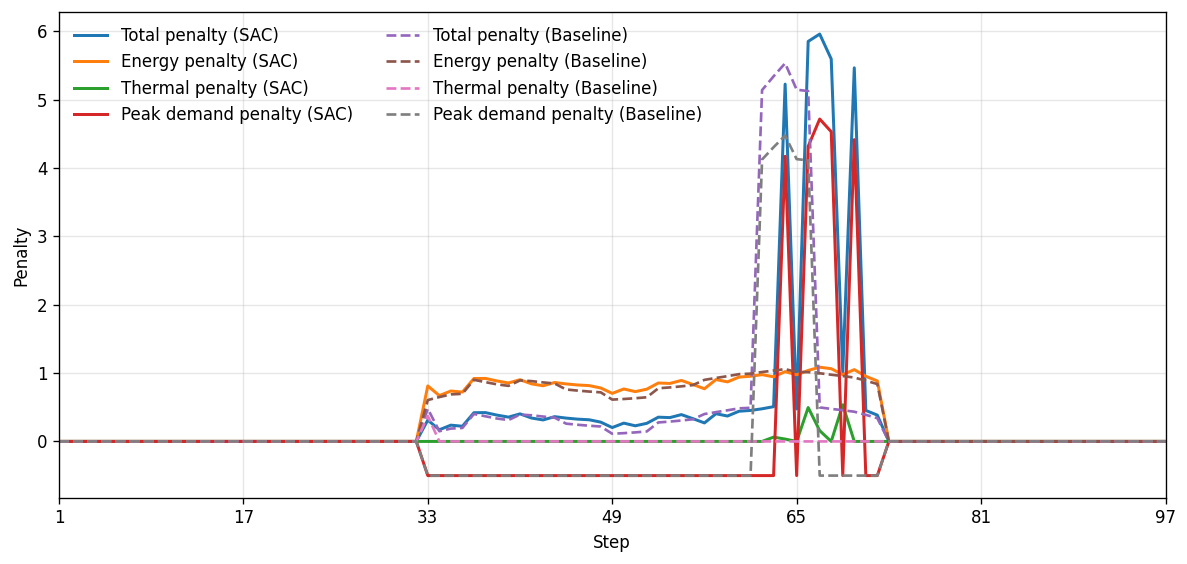

In [31]:
plt.figure(figsize=(10, 4.8), dpi=120)

sac_total_penalty = sac_penalty_df["EnergyPenalty"] + sac_penalty_df["ThermalPenalty"] + sac_penalty_df["PeakDemandPenalty"]
plt.plot(step_axis(sac_penalty_df), sac_total_penalty, linewidth=1.8, label="Total penalty (SAC)")
plt.plot(step_axis(sac_penalty_df), sac_penalty_df["EnergyPenalty"], linewidth=1.8, label="Energy penalty (SAC)")
plt.plot(step_axis(sac_penalty_df), sac_penalty_df["ThermalPenalty"], linewidth=1.8, label="Thermal penalty (SAC)")
plt.plot(step_axis(sac_penalty_df), sac_penalty_df["PeakDemandPenalty"], linewidth=1.8, label="Peak demand penalty (SAC)")

if baseline_penalty_df is not None:
    baseline_total_penalty = baseline_penalty_df["EnergyPenalty"] + baseline_penalty_df["ThermalPenalty"] + baseline_penalty_df["PeakDemandPenalty"]
    plt.plot(step_axis(baseline_penalty_df), baseline_total_penalty, linewidth=1.6, linestyle="--", label="Total penalty (Baseline)")
    plt.plot(step_axis(baseline_penalty_df), baseline_penalty_df["EnergyPenalty"], linewidth=1.6, linestyle="--", label="Energy penalty (Baseline)")
    plt.plot(step_axis(baseline_penalty_df), baseline_penalty_df["ThermalPenalty"], linewidth=1.6, linestyle="--", label="Thermal penalty (Baseline)")
    plt.plot(step_axis(baseline_penalty_df), baseline_penalty_df["PeakDemandPenalty"], linewidth=1.6, linestyle="--", label="Peak demand penalty (Baseline)")

plt.xlabel("Step")
plt.ylabel("Penalty")
plt.xlim(1, len(sac_penalty_df))
plt.xticks(x_ticks)
plt.grid(True, alpha=0.3)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()
